In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from scipy.stats import fisher_exact

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ------------------------------------------------------------------
# 데이터 로드 및 B(진해거담제) 서브셋 추출
# ------------------------------------------------------------------
df = pd.read_csv('FDA_adverse_events_final.csv', low_memory=False)
r = df[df['WHO_ATC'] == 'R'].copy()

def first_segment(s):
    return '' if pd.isna(s) else s.split(';')[0]

r['first_seg'] = r['suspect_drug'].apply(first_segment)

def classify(s):
    s = s.upper()
    if re.search(r'^IBUPROFEN$', s):
        return 'D'
    if re.search(r'^ACETAMINOPHEN$', s):
        return 'G'
    if re.search(r'\bPM\b|SLEEPGEL|SLEEP.?AID|UNISOM', s):
        return 'D'
    if re.search(r'NAPROXEN', s) and re.search(r'DIPHENHYDRAMINE', s):
        return 'D'
    if re.search(r'-D\b|ALLEGRA.?D|ZYRTEC.?D', s) or \
       (re.search(r'PSEUDOEPHEDRINE', s) and re.search(r'CETIRIZINE|FEXOFENADINE|LORATADINE', s)):
        return 'E'
    if re.search(r'CETIRIZINE|FEXOFENADINE|LORATADINE|LEVOCETIRIZINE|DIPHENHYDRAMINE|REACTINE|XYZAL|ALLEGRA(?!.?D)', s):
        return 'A'
    if re.search(r'PSEUDOEPHEDRINE|PHENYLEPHRINE|OXYMETAZOLINE|SUDAFED', s):
        return 'C'
    if re.search(r'GUAIFENESIN|DEXTROMETHORPHAN', s):
        return 'B'
    if re.search(r'FLUTICASONE', s):
        return 'F'
    return 'H'

r['group'] = r['first_seg'].apply(classify)
b = r[r['group'] == 'B'].copy()
rest = df[~df.index.isin(b.index)].copy()
n_b, n_rest = len(b), len(rest)


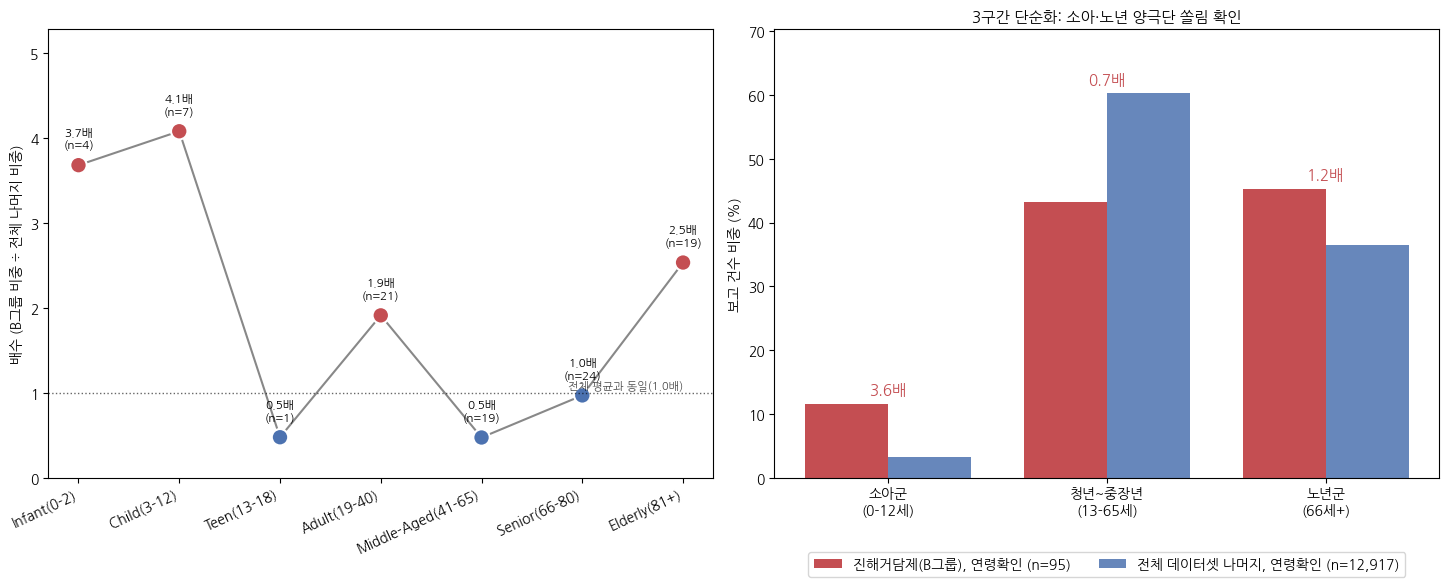

=== 7구간 배수 ===
Infant(0-2)          3.68배 (n=4)
Child(3-12)          4.08배 (n=7)
Teen(13-18)          0.48배 (n=1)
Adult(19-40)         1.91배 (n=21)
Middle-Aged(41-65)   0.47배 (n=19)
Senior(66-80)        0.97배 (n=24)
Elderly(81+)         2.54배 (n=19)

=== 3구간 단순화 배수 ===
소아군 (0-12세)          B 11.6% vs 전체 3.2%  배수=3.65
청년~중장년 (13-65세)      B 43.2% vs 전체 60.3%  배수=0.72
노년군 (66세+)           B 45.3% vs 전체 36.5%  배수=1.24


In [2]:
RED = '#C44E52'
BLUE = '#4C72B0'
GREY = '#888888'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ==================================================================
# 왼쪽 그림: 7개 연령 구간 배수(ratio) 라인 - 실제 형태(지그재그) 그대로 표시
# ==================================================================
age_order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
             'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']

b_cnt = b['age_group'].value_counts().reindex(age_order).fillna(0)
b_pct = b_cnt / n_b * 100
rest_pct = rest['age_group'].value_counts(normalize=True).reindex(age_order).fillna(0) * 100
ratio = (b_pct / rest_pct).replace([np.inf, -np.inf], np.nan)

x = np.arange(len(age_order))
colors = [RED if v >= 1 else BLUE for v in ratio]
ax1.plot(x, ratio, color=GREY, linewidth=1.5, zorder=1)
ax1.scatter(x, ratio, c=colors, s=140, zorder=2, edgecolor='white', linewidth=1.5)
ax1.axhline(1.0, color='black', linewidth=1, linestyle=':', alpha=0.6)
ax1.text(len(age_order)-1, 1.05, '전체 평균과 동일(1.0배)', ha='right', fontsize=8, color='black', alpha=0.7)

for i, ag in enumerate(age_order):
    ax1.annotate(f'{ratio[ag]:.1f}배\n(n={int(b_cnt[ag])})', xy=(i, ratio[ag]), xytext=(0, 12),
                 textcoords='offset points', ha='center', fontsize=8.5, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(age_order, rotation=25, ha='right')
ax1.set_ylabel('배수 (B그룹 비중 ÷ 전체 나머지 비중)')
ax1.set_ylim(0, ratio.max() + 1.2)

# ==================================================================
# 오른쪽 그림: 3개 큰 구간으로 단순화 - 진짜 U자 패턴 확인
# ==================================================================
bucket_map = {
    'Infant(0-2)': '소아군\n(0-12세)', 'Child(3-12)': '소아군\n(0-12세)',
    'Teen(13-18)': '청년~중장년\n(13-65세)', 'Adult(19-40)': '청년~중장년\n(13-65세)',
    'Middle-Aged(41-65)': '청년~중장년\n(13-65세)',
    'Senior(66-80)': '노년군\n(66세+)', 'Elderly(81+)': '노년군\n(66세+)',
}
# 연령 Unknown 행은 양쪽 그룹에서 동일하게 제외 (분모를 "연령 확인 가능 케이스"로 통일)
b_known = b[b['age_group'].isin(bucket_map.keys())].copy()
rest_known = rest[rest['age_group'].isin(bucket_map.keys())].copy()
b_known['bucket'] = b_known['age_group'].map(bucket_map)
rest_known['bucket'] = rest_known['age_group'].map(bucket_map)
n_b_known, n_rest_known = len(b_known), len(rest_known)

bucket_order = ['소아군\n(0-12세)', '청년~중장년\n(13-65세)', '노년군\n(66세+)']
b_bcnt = b_known['bucket'].value_counts().reindex(bucket_order).fillna(0)
b_bpct = b_bcnt / n_b_known * 100
rest_bcnt = rest_known['bucket'].value_counts().reindex(bucket_order).fillna(0)
rest_bpct = rest_bcnt / n_rest_known * 100
bratio = (b_bpct / rest_bpct)

xb = np.arange(len(bucket_order))
w = 0.38
ax2.bar(xb - w/2, b_bpct, width=w, color=RED, label=f'진해거담제(B그룹), 연령확인 (n={n_b_known})')
ax2.bar(xb + w/2, rest_bpct, width=w, color=BLUE, alpha=0.85, label=f'전체 데이터셋 나머지, 연령확인 (n={n_rest_known:,})')

for i, bk in enumerate(bucket_order):
    top = max(b_bpct[bk], rest_bpct[bk])
    ax2.text(i, top + 1.5, f'{bratio[bk]:.1f}배', ha='center', fontsize=11, fontweight='bold', color=RED)

ax2.set_xticks(xb)
ax2.set_xticklabels(bucket_order)
ax2.set_ylabel('보고 건수 비중 (%)')
ax2.set_title('3구간 단순화: 소아·노년 양극단 쏠림 확인', fontsize=11, fontweight='bold')
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
ax2.set_ylim(0, max(b_bpct.max(), rest_bpct.max()) + 10)

plt.tight_layout()
plt.show()

# 콘솔 요약
print("=== 7구간 배수 ===")
for ag in age_order:
    print(f"{ag:20s} {ratio[ag]:.2f}배 (n={int(b_cnt[ag])})")
print()
print("=== 3구간 단순화 배수 ===")
for bk in bucket_order:
    print(f"{bk.replace(chr(10),' '):20s} B {b_bpct[bk]:.1f}% vs 전체 {rest_bpct[bk]:.1f}%  배수={bratio[bk]:.2f}")


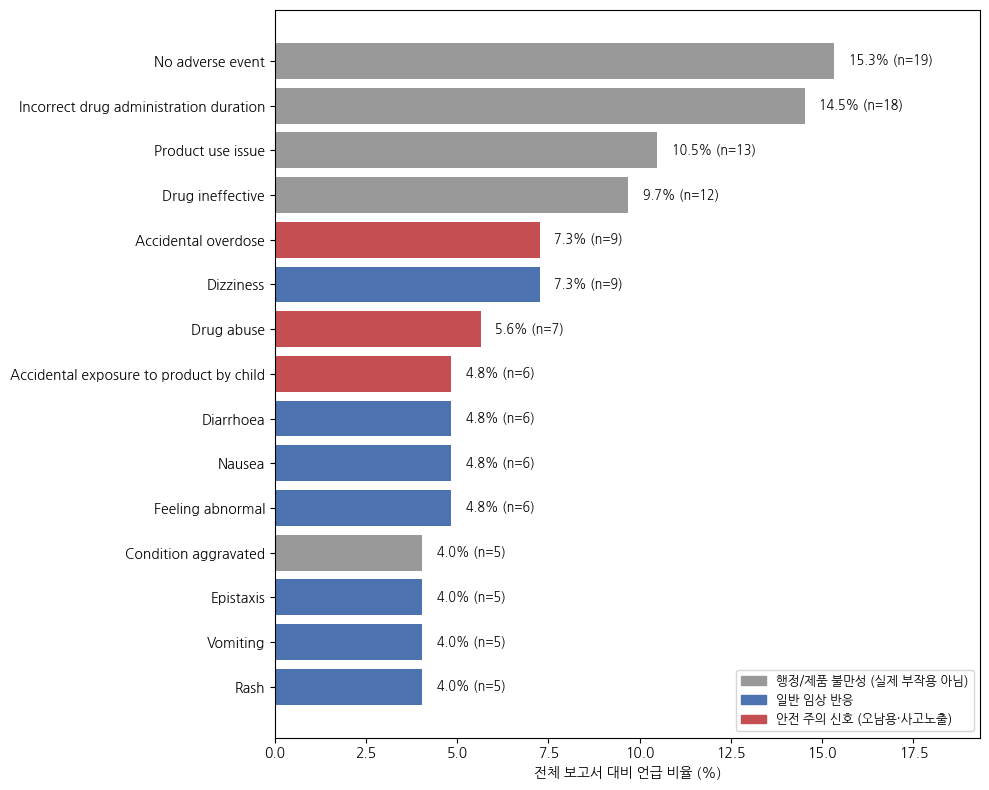

=== 상위 15개 반응 (카테고리 포함) ===
No adverse event                               19건 (15.3%)  [행정성]
Incorrect drug administration duration         18건 (14.5%)  [행정성]
Product use issue                              13건 (10.5%)  [행정성]
Drug ineffective                               12건 (9.7%)  [행정성]
Accidental overdose                             9건 (7.3%)  [안전신호]
Dizziness                                       9건 (7.3%)  [일반임상]
Drug abuse                                      7건 (5.6%)  [안전신호]
Accidental exposure to product by child         6건 (4.8%)  [안전신호]
Diarrhoea                                       6건 (4.8%)  [일반임상]
Nausea                                          6건 (4.8%)  [일반임상]
Feeling abnormal                                6건 (4.8%)  [일반임상]
Condition aggravated                            5건 (4.0%)  [행정성]
Epistaxis                                       5건 (4.0%)  [일반임상]
Vomiting                                        5건 (4.0%)  [일반임상]
Rash                                            5건

In [3]:
GREY = '#999999'   # 행정/제품 불만성 보고 (실제 부작용 아님)
BLUE = '#4C72B0'   # 일반 임상 반응
RED = '#C44E52'    # 안전 주의 신호 (오남용/사고노출)

# ------------------------------------------------------------------
# reactions 필드를 세미콜론으로 분리해서 개별 반응 용어 집계
# ------------------------------------------------------------------
all_reactions = []
for s in b['reactions'].dropna():
    all_reactions.extend([p.strip() for p in s.split(';')])

cnt = Counter(all_reactions)
top15 = cnt.most_common(15)

# 카테고리 분류 (수동 매핑)
admin_terms = {'No adverse event', 'Incorrect drug administration duration',
               'Product use issue', 'Drug ineffective', 'Condition aggravated'}
safety_terms = {'Accidental overdose', 'Drug abuse', 'Accidental exposure to product by child'}

def get_color(term):
    if term in safety_terms:
        return RED
    if term in admin_terms:
        return GREY
    return BLUE

labels = [t for t, c in top15][::-1]
counts = [c for t, c in top15][::-1]
pcts = [c / n_b * 100 for c in counts]
colors = [get_color(t) for t in labels]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(labels, pcts, color=colors)

for i, (p, c) in enumerate(zip(pcts, counts)):
    ax.text(p + 0.4, i, f'{p:.1f}% (n={c})', va='center', fontsize=9)

ax.set_xlabel('전체 보고서 대비 언급 비율 (%)')
ax.set_xlim(0, max(pcts) + 4)

legend_patches = [
    mpatches.Patch(color=GREY, label='행정/제품 불만성 (실제 부작용 아님)'),
    mpatches.Patch(color=BLUE, label='일반 임상 반응'),
    mpatches.Patch(color=RED, label='안전 주의 신호 (오남용·사고노출)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("=== 상위 15개 반응 (카테고리 포함) ===")
for t, c in top15:
    cat = '안전신호' if t in safety_terms else ('행정성' if t in admin_terms else '일반임상')
    print(f"{t:45s} {c:3d}건 ({c/n_b*100:.1f}%)  [{cat}]")


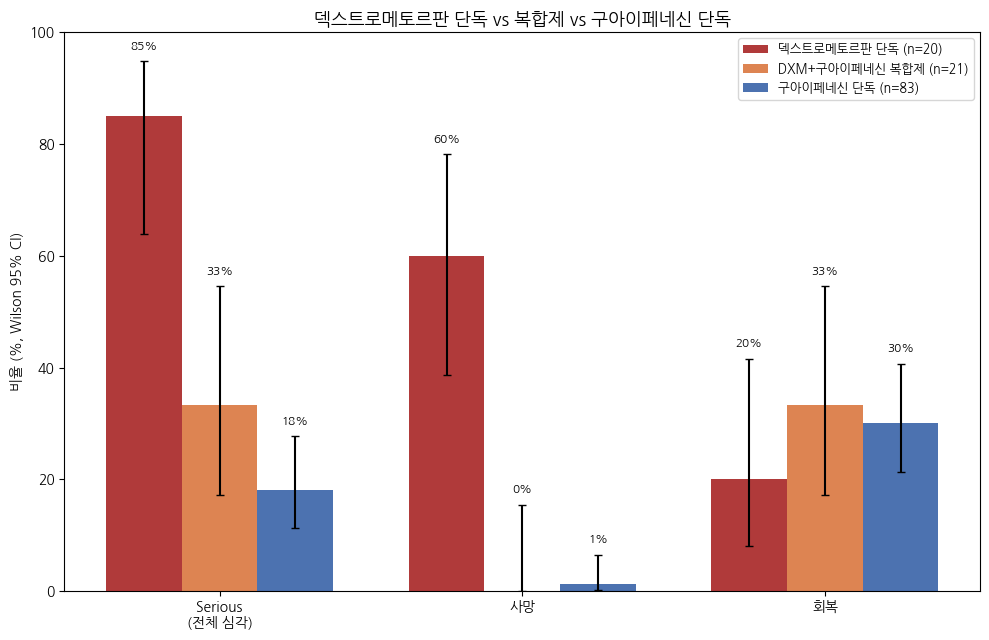

=== 유형별 요약 ===
덱스트로메토르판 단독               n= 20  serious= 85.0%  사망= 60.0%  회복= 20.0%
DXM+구아이페네신 복합제            n= 21  serious= 33.3%  사망=  0.0%  회복= 33.3%
구아이페네신 단독                 n= 83  serious= 18.1%  사망=  1.2%  회복= 30.1%


In [4]:
# 위험도 순서에 따른 색상 (진한 빨강 -> 주황 -> 파랑)
COLOR_DXM단독 = '#B03A3A'      # 가장 위험한 유형
COLOR_복합제 = '#DD8452'       # 중간
COLOR_구아이페네신 = '#4C72B0'  # 가장 순한 유형

# 성분 조합에 따라 3가지 유형으로 분류
b['has_dxm'] = b['first_seg'].str.upper().str.contains('DEXTROMETHORPHAN')
b['has_gua'] = b['first_seg'].str.upper().str.contains('GUAIFENESIN')
b['type'] = np.where(b['has_dxm'] & b['has_gua'], 'DXM+구아이페네신\n복합제',
             np.where(b['has_dxm'], '덱스트로메토르판\n단독',
             np.where(b['has_gua'], '구아이페네신\n단독', '기타')))

type_order = ['덱스트로메토르판\n단독', 'DXM+구아이페네신\n복합제', '구아이페네신\n단독']
colors = [COLOR_DXM단독, COLOR_복합제, COLOR_구아이페네신]


# ------------------------------------------------------------------
# Wilson 95% 신뢰구간 계산 함수
# ------------------------------------------------------------------
def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = p + z**2 / (2 * n)
    margin = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return (center - margin) / denom, (center + margin) / denom


metrics = [('serious', 'Serious\n(전체 심각)'), ('is_fatal', '사망'), ('patient_recovered', '회복')]

fig, ax = plt.subplots(figsize=(10, 6.5))
x = np.arange(len(metrics))
w = 0.25

for i, t in enumerate(type_order):
    sub = b[b['type'] == t]
    n = len(sub)
    vals, errs = [], []
    for col, _ in metrics:
        if sub[col].dtype == bool:
            k = sub[col].sum()
        else:
            k = (sub[col] == 'Yes').sum()
        p = k / n * 100
        lo, hi = wilson_ci(k, n)
        vals.append(p)
        errs.append((p - lo * 100, hi * 100 - p))
    errs = np.array(errs).T
    offset = (i - 1) * w
    bars = ax.bar(x + offset, vals, width=w, color=colors[i], yerr=errs, capsize=3,
                  label=f'{t.replace(chr(10), " ")} (n={n})')
    for j, v in enumerate(vals):
        ax.text(x[j] + offset, v + errs[1][j] + 2, f'{v:.0f}%', ha='center', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels([m[1] for m in metrics])
ax.set_ylabel('비율 (%, Wilson 95% CI)')
ax.set_title('덱스트로메토르판 단독 vs 복합제 vs 구아이페네신 단독',
              fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# 콘솔 요약
print("=== 유형별 요약 ===")
for t in type_order:
    sub = b[b['type'] == t]
    n = len(sub)
    serious = (sub['serious'] == 'Yes').mean() * 100
    fatal = sub['is_fatal'].mean() * 100
    rec = sub['patient_recovered'].mean() * 100
    print(f"{t.replace(chr(10),' '):25s} n={n:3d}  serious={serious:5.1f}%  사망={fatal:5.1f}%  회복={rec:5.1f}%")


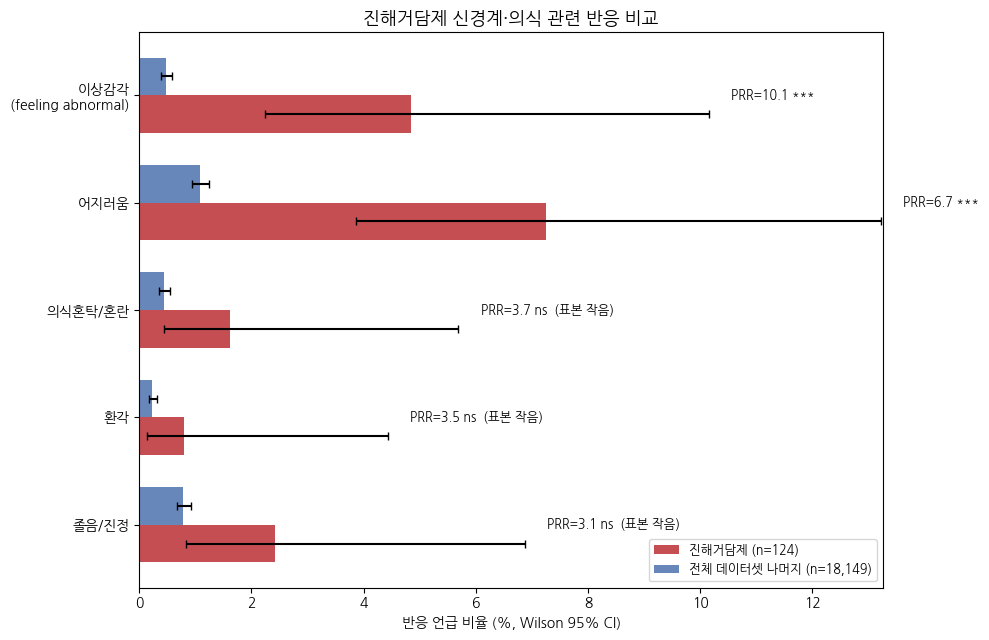

=== 신경계·의식 관련 반응 비교 ===
졸음/진정                     B 2.42% (n=3)  vs 전체 0.79%  PRR=3.07  p=7.7e-02
환각                        B 0.81% (n=1)  vs 전체 0.23%  PRR=3.48  p=2.5e-01
의식혼탁/혼란                   B 1.61% (n=2)  vs 전체 0.44%  PRR=3.71  p=1.0e-01
어지러움                      B 7.26% (n=9)  vs 전체 1.08%  PRR=6.72  p=1.1e-05
이상감각 (feeling abnormal)   B 4.84% (n=6)  vs 전체 0.48%  PRR=10.09  p=4.1e-05


In [5]:
RED = '#C44E52'
BLUE = '#4C72B0'

def wilson_ci(k, n, z=1.96):
    p = k / n
    denom = 1 + z**2 / n
    center = p + z**2 / (2 * n)
    margin = z * np.sqrt((p * (1 - p) / n) + (z**2 / (4 * n**2)))
    return (center - margin) / denom, (center + margin) / denom

def stat_pair(pattern):
    k1 = b['reactions'].str.contains(pattern, case=False, na=False, regex=True).sum()
    k2 = rest['reactions'].str.contains(pattern, case=False, na=False, regex=True).sum()
    p1, p2 = k1 / n_b, k2 / n_rest
    prr = p1 / p2 if p2 > 0 else np.nan
    _, p_fisher = fisher_exact([[k1, n_b - k1], [k2, n_rest - k2]])
    lo1, hi1 = wilson_ci(k1, n_b)
    lo2, hi2 = wilson_ci(k2, n_rest)
    return dict(k1=k1, p1=p1*100, p2=p2*100, prr=prr, p_fisher=p_fisher,
                err1=(p1*100-lo1*100, hi1*100-p1*100), err2=(p2*100-lo2*100, hi2*100-p2*100))

def sig_stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))

# 확인할 신경계/의식 관련 반응 목록
items = [
    ('어지러움', 'dizz'),
    ('이상감각\n(feeling abnormal)', 'feeling abnormal'),
    ('졸음/진정', 'somnolen|drowsi|sedation'),
    ('의식혼탁/혼란', 'confus'),
    ('환각', 'hallucin'),
]

rows = []
for label, pattern in items:
    stat = stat_pair(pattern)
    stat['label'] = label
    rows.append(stat)

rows.sort(key=lambda x: x['prr'])  # PRR 오름차순 -> 위로 갈수록 격차 큼

fig, ax = plt.subplots(figsize=(10, 6.5))
y = np.arange(len(rows))
h = 0.35

p1_vals = [r['p1'] for r in rows]
p2_vals = [r['p2'] for r in rows]
err1 = np.array([r['err1'] for r in rows]).T
err2 = np.array([r['err2'] for r in rows]).T

ax.barh(y - h/2, p1_vals, height=h, color=RED, xerr=err1, capsize=3,
        label=f'진해거담제 (n={n_b})')
ax.barh(y + h/2, p2_vals, height=h, color=BLUE, alpha=0.85, xerr=err2, capsize=3,
        label=f'전체 데이터셋 나머지 (n={n_rest:,})')

ax.set_yticks(y)
ax.set_yticklabels([r['label'] for r in rows])
ax.set_xlabel('반응 언급 비율 (%, Wilson 95% CI)')
ax.set_title('진해거담제 신경계·의식 관련 반응 비교', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)

for i, r in enumerate(rows):
    right = max(r['p1'] + r['err1'][1], r['p2'] + r['err2'][1])
    note = '' if r['k1'] >= 5 else '  (표본 작음)'
    ax.text(right + 0.4, i, f"PRR={r['prr']:.1f} {sig_stars(r['p_fisher'])}{note}",
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, max(p1_vals + p2_vals) + 6)
plt.tight_layout()
plt.show()

# 콘솔 요약
print("=== 신경계·의식 관련 반응 비교 ===")
for r in rows:
    print(f"{r['label'].replace(chr(10),' '):25s} B {r['p1']:.2f}% (n={r['k1']})  vs 전체 {r['p2']:.2f}%  PRR={r['prr']:.2f}  p={r['p_fisher']:.1e}")
